# DDPM sur CIFAR-10

## 1. Configuration & chemins

In [18]:
import os, sys, math, time, json
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import CIFAR10
from torchvision.transforms import v2
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

ROOT = Path("/home/onyxia/work/ddpm")
DATA_DIR = ROOT / "dataset"
SAVE_DIR = ROOT / "weights"
SAMPLE_DIR = ROOT / "samples"

for d in (DATA_DIR, SAVE_DIR, SAMPLE_DIR):
    d.mkdir(parents=True, exist_ok=True)
CKPT_LAST = SAVE_DIR / "ddpm_last.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)

print(f"root     : {ROOT}")
print(f"device   : {device}", torch.cuda.get_device_name(0) if device.type == "cuda" else "")
print(f"cpu count: {os.cpu_count()}")

root     : /home/onyxia/work/ddpm
device   : cuda Tesla T4
cpu count: 72


In [19]:
import os

def usable_cpus():
    try:                                    # cgroup v2
        quota, period = open("/sys/fs/cgroup/cpu.max").read().split()
        if quota != "max":
            return max(1, round(int(quota) / int(period)))
    except Exception:
        pass
    try:                                    # cgroup v1
        q = int(open("/sys/fs/cgroup/cpu/cpu.cfs_quota_us").read())
        p = int(open("/sys/fs/cgroup/cpu/cpu.cfs_period_us").read())
        if q > 0:
            return max(1, round(q / p))
    except Exception:
        pass
    return len(os.sched_getaffinity(0))

print("os.cpu_count() :", os.cpu_count(), "| réellement alloués :", usable_cpus())

os.cpu_count() : 72 | réellement alloués : 30


## 2. Hyperparamètres

In [ ]:
timesteps = 1000
beta1, beta2 = 1e-4, 0.02

n_feat = 128          # 8,4 M params — la T4 (16 Go) encaisse largement
height = 32
in_channels = 3

batch_size = 128
lr = 2e-4
epochs = 200
subsample = 1         # dataset complet : 50 000 images
SAVE_EVERY = 20
RESUME = True
USE_EMA = True
USE_AMP = True        # fp16, la T4 a des tensor cores fp16 (surtout PAS bf16 :
                      # Turing ne le gère pas nativement, ce serait plus lent)

NUM_WORKERS = min(8, usable_cpus())
torch.backends.cudnn.benchmark = True   # shapes fixes -> autotune cuDNN

# Un num_workers trop grand fait plus de mal que de bien : 40 batches/epoch
print("num_workers =", NUM_WORKERS)

num_workers = 8


## 3. Données

train: 50000 images | test: 10000 images
batch: torch.Size([128, 3, 32, 32]) torch.Size([128]) min=-1.00 max=1.00


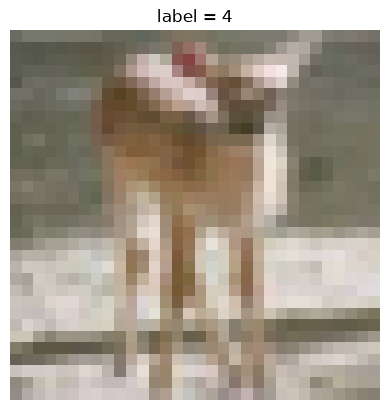

In [21]:
tf = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[.5, .5, .5], std=[.5, .5, .5]),   # -> [-1, 1]
])

training_data = CIFAR10(root=str(DATA_DIR), train=True,  download=True, transform=tf)
test_data     = CIFAR10(root=str(DATA_DIR), train=False, download=True, transform=tf)

data_train = Subset(training_data, range(0, len(training_data), subsample))
data_test  = Subset(test_data,     range(0, len(test_data),     subsample))
print(f"train: {len(data_train)} images | test: {len(data_test)} images")

dl_kwargs = dict(batch_size=batch_size, shuffle=True, pin_memory=(device.type == "cuda"),
                 num_workers=NUM_WORKERS, drop_last=True)
if NUM_WORKERS > 0:
    dl_kwargs["persistent_workers"] = True          # évite de respawner à chaque epoch

train_dataloader = DataLoader(data_train, **dl_kwargs)
test_dataloader  = DataLoader(data_test,  **dl_kwargs)

# Vérification visuelle
xb, yb = next(iter(train_dataloader))
print("batch:", xb.shape, yb.shape, f"min={xb.min():.2f} max={xb.max():.2f}")
plt.imshow((xb[0] * .5 + .5).clamp(0, 1).permute(1, 2, 0))
plt.axis("off"); plt.title(f"label = {yb[0].item()}"); plt.show()

## 4. Planificateur de bruit

`alpha_hat` est calculé via `cumsum(log)` plutôt que `cumprod` : c'est équivalent et
numériquement plus stable.

In [22]:
class NoiseScheduler:
    def __init__(self, timesteps, beta_start=1e-4, beta_end=0.02, device="cpu"):
        self.timesteps = timesteps
        self.device = device

        self.beta = torch.linspace(beta_start, beta_end, timesteps, device=device)
        self.alpha = 1.0 - self.beta
        self.alpha_hat = torch.cumsum(self.alpha.log(), dim=0).exp()

        # Forward
        self.sqrt_alpha_hat = self.alpha_hat.sqrt()
        self.sqrt_one_minus_alpha_hat = (1.0 - self.alpha_hat).sqrt()

        # Reverse
        self.sqrt_inv_alpha = (1.0 / self.alpha).sqrt()
        self.eps_coef = self.beta / self.sqrt_one_minus_alpha_hat
        self.sigma = self.beta.sqrt()

    def add_noise(self, x_0, t, noise=None):
        """q(x_t | x_0)"""
        if noise is None:
            noise = torch.randn_like(x_0)
        s1 = self.sqrt_alpha_hat[t].view(-1, 1, 1, 1)
        s2 = self.sqrt_one_minus_alpha_hat[t].view(-1, 1, 1, 1)
        return s1 * x_0 + s2 * noise, noise

    @torch.no_grad()
    def sample_step(self, model, x_t, t_idx):
        """Un pas de p(x_{t-1} | x_t)"""
        t = torch.full((x_t.shape[0],), t_idx, device=self.device, dtype=torch.long)
        pred_noise = model(x_t, t)
        mean = self.sqrt_inv_alpha[t_idx] * (x_t - self.eps_coef[t_idx] * pred_noise)
        if t_idx > 0:
            return mean + self.sigma[t_idx] * torch.randn_like(x_t)
        return mean


scheduler = NoiseScheduler(timesteps, beta1, beta2, device)
print("alpha_hat[0] =", scheduler.alpha_hat[0].item(),
      "| alpha_hat[-1] =", scheduler.alpha_hat[-1].item())

alpha_hat[0] = 0.9998999834060669 | alpha_hat[-1] = 4.0358358091907576e-05


### Visualisation du processus forward

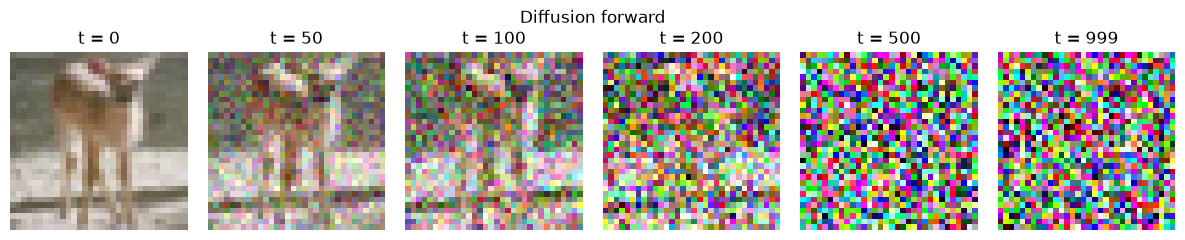

In [23]:
steps = [0, 50, 100, 200, 500, 999]
x_0 = xb[:1].to(device)

noisy = [scheduler.add_noise(x_0, torch.tensor([s], device=device))[0] for s in steps]
grid = make_grid(torch.cat(noisy), nrow=len(steps))

fig, axes = plt.subplots(1, len(steps), figsize=(2 * len(steps), 2.4))
for ax, s, img in zip(axes, steps, noisy):
    ax.imshow((img[0] * .5 + .5).clamp(0, 1).permute(1, 2, 0).cpu())
    ax.set_title(f"t = {s}"); ax.axis("off")
plt.suptitle("Diffusion forward"); plt.tight_layout(); plt.show()

## 5. Architecture du U-Net

In [ ]:
def gn(channels, max_groups=32):
    g = max_groups
    while channels % g != 0:
        g //= 2
    return nn.GroupNorm(g, channels)


class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim=128):
        super().__init__()
        assert dim % 2 == 0, "dim doit être pair"
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device) / (half - 1)
        )
        angles = t.float()[:, None] * freqs[None, :]
        return torch.cat([angles.sin(), angles.cos()], dim=1)


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim):
        super().__init__()
        self.norm1 = gn(in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.time_proj = nn.Linear(time_emb_dim, out_channels)

        self.norm2 = gn(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.act = nn.SiLU()

        self.skip = (nn.Conv2d(in_channels, out_channels, 1)
                     if in_channels != out_channels else nn.Identity())

    def forward(self, x, t_emb):
        h = self.conv1(self.act(self.norm1(x)))
        h = h + self.time_proj(self.act(t_emb))[:, :, None, None]
        h = self.conv2(self.act(self.norm2(h)))
        return h + self.skip(x)


class SelfAttention(nn.Module):
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.norm = gn(channels)
        self.attn = nn.MultiheadAttention(channels, num_heads, batch_first=True)

    def forward(self, x):
        b, c, h, w = x.shape
        y = self.norm(x).view(b, c, h * w).permute(0, 2, 1)
        y, _ = self.attn(y, y, y)
        return x + y.permute(0, 2, 1).view(b, c, h, w)

In [ ]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, n_feat=64):
        super().__init__()
        time_dim = n_feat * 4

        self.time_embed = nn.Sequential(
            SinusoidalPositionEmbeddings(n_feat),
            nn.Linear(n_feat, time_dim), nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        self.init_conv = nn.Conv2d(in_channels, n_feat, 3, padding=1)

        # Encoder            32x32
        self.down_block1 = ResidualBlock(n_feat, n_feat, time_dim)
        self.down_conv1  = nn.Conv2d(n_feat, n_feat, 3, stride=2, padding=1)   # -> 16x16
        self.down_block2 = ResidualBlock(n_feat, 2 * n_feat, time_dim)
        self.down_attn   = SelfAttention(2 * n_feat)
        self.down_conv2  = nn.Conv2d(2 * n_feat, 2 * n_feat, 3, stride=2, padding=1)  # -> 8x8

        # Bottleneck          8x8
        self.mid_block1 = ResidualBlock(2 * n_feat, 2 * n_feat, time_dim)
        self.mid_attn   = SelfAttention(2 * n_feat)
        self.mid_block2 = ResidualBlock(2 * n_feat, 2 * n_feat, time_dim)

        # Decoder
        self.up_conv2  = nn.ConvTranspose2d(2 * n_feat, 2 * n_feat, 4, stride=2, padding=1)
        self.up_block2 = ResidualBlock(4 * n_feat, n_feat, time_dim)
        self.up_attn   = SelfAttention(n_feat)
        self.up_conv1  = nn.ConvTranspose2d(n_feat, n_feat, 4, stride=2, padding=1)
        self.up_block1 = ResidualBlock(2 * n_feat, n_feat, time_dim)

        self.out_norm = gn(n_feat)
        self.out_act  = nn.SiLU()
        self.out_conv = nn.Conv2d(n_feat, in_channels, 3, padding=1)
        nn.init.zeros_(self.out_conv.weight)      # départ à epsilon=0, stabilise le début
        nn.init.zeros_(self.out_conv.bias)

    def forward(self, x, t):
        t_emb = self.time_embed(t)

        h  = self.init_conv(x)
        h1 = self.down_block1(h, t_emb)
        h  = self.down_conv1(h1)
        h  = self.down_block2(h, t_emb)
        h2 = self.down_attn(h)
        h  = self.down_conv2(h2)

        h = self.mid_block1(h, t_emb)
        h = self.mid_attn(h)
        h = self.mid_block2(h, t_emb)

        h = self.up_conv2(h)
        h = self.up_block2(torch.cat([h, h2], dim=1), t_emb)
        h = self.up_attn(h)
        h = self.up_conv1(h)
        h = self.up_block1(torch.cat([h, h1], dim=1), t_emb)

        return self.out_conv(self.out_act(self.out_norm(h)))

### Test de forme (à lancer avant l'entraînement)

In [26]:
_m = UNet(in_channels, n_feat).to(device)
_x = torch.randn(4, in_channels, height, height, device=device)
_t = torch.randint(0, timesteps, (4,), device=device)
with torch.no_grad():
    _out = _m(_x, _t)
print("output:", tuple(_out.shape), "| params:", f"{sum(p.numel() for p in _m.parameters())/1e6:.2f} M")
assert _out.shape == _x.shape
del _m, _x, _t, _out

output: (4, 3, 32, 32) | params: 8.43 M


## 6. EMA

Le papier DDPM entraîne les poids mais échantillonne avec une moyenne mobile exponentielle.

In [27]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.detach().clone().float()
                       for k, v in model.state_dict().items()
                       if v.dtype.is_floating_point}

    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            if k in self.shadow:
                self.shadow[k].mul_(self.decay).add_(v.detach().float(), alpha=1 - self.decay)

    @torch.no_grad()
    def copy_to(self, model):
        msd = model.state_dict()
        for k, v in self.shadow.items():
            msd[k].copy_(v)

    def state_dict(self):
        return self.shadow

    def load_state_dict(self, sd):
        self.shadow = {k: v.clone() for k, v in sd.items()}

## 7. Entraînement

In [28]:
model = UNet(in_channels, n_feat).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()
ema = EMA(model, decay=0.999) if USE_EMA else None
scaler = torch.amp.GradScaler(device.type, enabled=USE_AMP)

start_epoch, history = 0, []
if RESUME and CKPT_LAST.exists():
    ckpt = torch.load(CKPT_LAST, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scaler.load_state_dict(ckpt["scaler"])
    if ema is not None and ckpt.get("ema") is not None:
        ema.load_state_dict(ckpt["ema"])
    start_epoch = ckpt["epoch"] + 1
    history = ckpt.get("history", [])
    print(f"Reprise depuis l'epoch {start_epoch}")
else:
    print("Démarrage à zéro")


def save_ckpt(path, epoch):
    torch.save({
        "epoch": epoch,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scaler": scaler.state_dict(),
        "ema": ema.state_dict() if ema is not None else None,
        "history": history,
        "config": dict(n_feat=n_feat, timesteps=timesteps, beta1=beta1, beta2=beta2),
    }, path)


model.train()
for epoch in range(start_epoch, epochs):
    total, t0 = 0.0, time.time()
    pbar = tqdm(train_dataloader, desc=f"epoch {epoch+1}/{epochs}", leave=False)

    for x, _ in pbar:
        x = x.to(device, non_blocking=True)
        t = torch.randint(0, timesteps, (x.shape[0],), device=device)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=USE_AMP):
            x_t, noise = scheduler.add_noise(x, t)
            loss = criterion(model(x_t, t), noise)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        if ema is not None:
            ema.update(model)

        total += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg = total / len(train_dataloader)
    history.append(avg)
    print(f"epoch {epoch+1:3d}/{epochs} | MSE {avg:.5f} | {time.time()-t0:.1f}s")

    save_ckpt(CKPT_LAST, epoch)
    if (epoch + 1) % SAVE_EVERY == 0:
        save_ckpt(SAVE_DIR / f"ddpm_epoch{epoch+1:04d}.pt", epoch)

Reprise depuis l'epoch 200


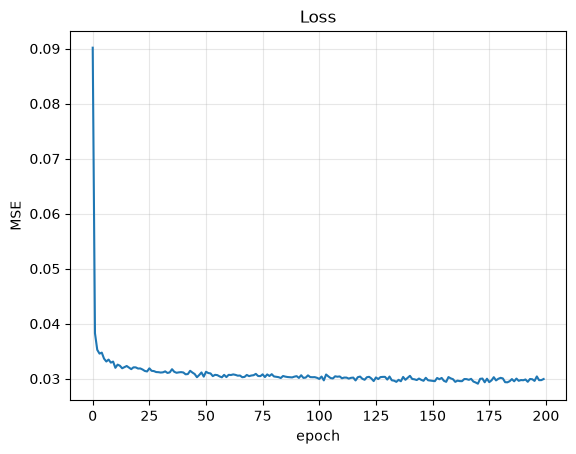

In [12]:
plt.plot(history)
plt.xlabel("epoch"); plt.ylabel("MSE"); plt.title("Loss"); plt.grid(alpha=.3); plt.show()

## 8. Échantillonnage

In [ ]:
# Modèle d'échantillonnage : les poids EMA si disponibles
sample_model = UNet(in_channels, n_feat).to(device)
sample_model.load_state_dict(model.state_dict())
if ema is not None:
    ema.copy_to(sample_model)
sample_model.eval()


@torch.no_grad()
def sample_trajectory(model, scheduler, steps_to_save, n_samples=4,
                      channels=3, size=32, progress=True):
    was_training = model.training
    model.eval()

    x = torch.randn(n_samples, channels, size, size, device=scheduler.device)
    target = set(steps_to_save)
    snapshots = []

    it = reversed(range(scheduler.timesteps))
    if progress:
        it = tqdm(it, total=scheduler.timesteps, desc="sampling", leave=False)

    for t_idx in it:
        if t_idx in target:
            snapshots.append((t_idx, x.clone()))
        x = scheduler.sample_step(model, x, t_idx)

    snapshots.append((None, x.clone()))
    model.train(was_training)
    return snapshots


@torch.no_grad()
def sample(model, scheduler, n_samples=16, channels=3, size=32):
    was_training = model.training
    model.eval()
    x = torch.randn(n_samples, channels, size, size, device=scheduler.device)
    for t_idx in tqdm(reversed(range(scheduler.timesteps)),
                      total=scheduler.timesteps, desc="sampling", leave=False):
        x = scheduler.sample_step(model, x, t_idx)
    model.train(was_training)
    return x

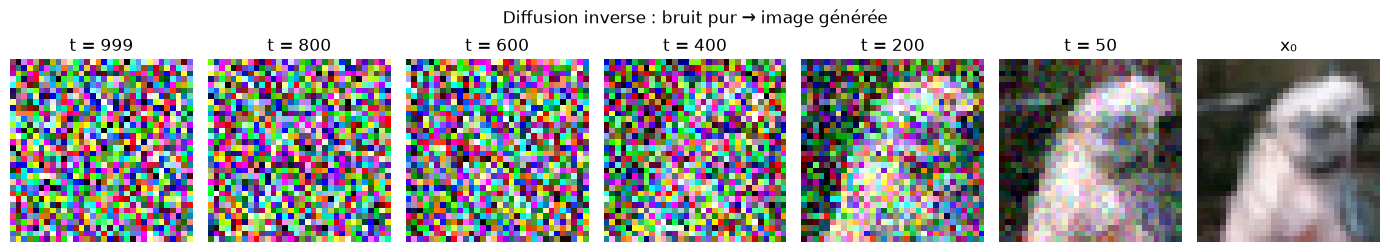

In [14]:
steps_to_save = [999, 800, 600, 400, 200, 50]
snaps = sample_trajectory(sample_model, scheduler, steps_to_save, n_samples=1)

fig, axes = plt.subplots(1, len(snaps), figsize=(2 * len(snaps), 2.6))
for ax, (t_idx, img) in zip(axes, snaps):
    ax.imshow((img[0] * .5 + .5).clamp(0, 1).permute(1, 2, 0).cpu())
    ax.set_title("x₀" if t_idx is None else f"t = {t_idx}")
    ax.axis("off")
plt.suptitle("Diffusion inverse : bruit pur → image générée")
plt.tight_layout(); plt.show()

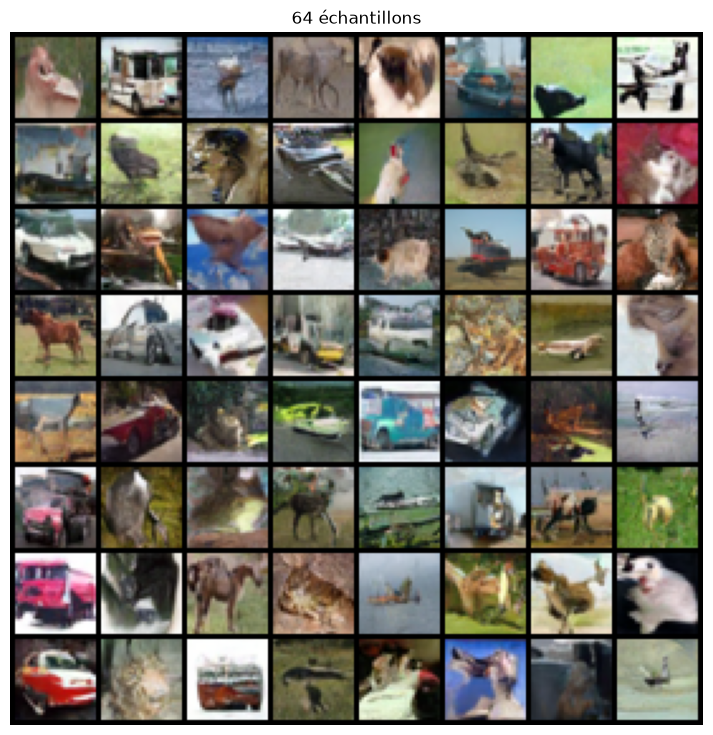

écrit dans /home/onyxia/work/ddpm/samples/samples.png


In [15]:
imgs = sample(sample_model, scheduler, n_samples=64)
grid = make_grid((imgs * .5 + .5).clamp(0, 1).cpu(), nrow=8, padding=2)

plt.figure(figsize=(9, 9))
plt.imshow(grid.permute(1, 2, 0)); plt.axis("off")
plt.title("64 échantillons"); plt.show()

from torchvision.utils import save_image
save_image(grid, SAMPLE_DIR / "samples.png")
print("écrit dans", SAMPLE_DIR / "samples.png")

## 9. Synchronisation S3 (Onyxia / SSP Cloud)

À lancer après l'entraînement, ou périodiquement. Le bucket personnel porte le nom
d'utilisateur. Le volume du service peut disparaître ; le bucket S3, non.

In [17]:
# Ne fait rien hors Onyxia
import subprocess, shutil

BUCKET = "gfogato"
S3_PREFIX = f"s3/{BUCKET}/ddpm"

def s3_sync(direction="up"):
    if shutil.which("mc") is None:
        raise RuntimeError("mc introuvable — hors Onyxia ?")
    pairs = [(SAVE_DIR, f"{S3_PREFIX}/weights"), (SAMPLE_DIR, f"{S3_PREFIX}/samples")]
    for local, remote in pairs:
        src, dst = (str(local), remote) if direction == "up" else (remote, str(local))
        r = subprocess.run(["mc", "mirror", "--overwrite", src, dst],
                           capture_output=True, text=True)
        if r.returncode != 0:
            raise RuntimeError(f"mc mirror a échoué ({src} -> {dst}) :\n{r.stderr}")
        print("ok", src, "->", dst)

s3_sync("up")
# s3_sync("down")

ok /home/onyxia/work/ddpm/weights -> s3/gfogato/ddpm/weights
ok /home/onyxia/work/ddpm/samples -> s3/gfogato/ddpm/samples


# Fine tuning sur une seule classe

In [30]:
CLASS_ID  = 3 # Chat
BASE_CKPT = SAVE_DIR / "ddpm_epoch0200.pt"
FT_DIR    = SAVE_DIR / f"ft_class{CLASS_ID}"; FT_DIR.mkdir(parents=True, exist_ok=True)
FT_CKPT   = FT_DIR / "ddpm_last.pt"
ft_lr, ft_epochs, ft_ema_decay = 2e-5, 20, 0.99

In [31]:
# Données
idx = [i for i, y in enumerate(training_data.targets) if y == CLASS_ID]
dl_class = DataLoader(Subset(training_data, idx), batch_size=batch_size, shuffle=True,
                      pin_memory=(device.type == "cuda"), num_workers=4, drop_last=True)
print(len(idx), "images |", len(dl_class), "batches/epoch")

5000 images | 39 batches/epoch


In [32]:
# Modèle à fine-tune
ft_model = UNet(in_channels, n_feat).to(device)
base = torch.load(BASE_CKPT, map_location=device, weights_only=False)
ft_model.load_state_dict(base["model"])
if base.get("ema"):
    sd = ft_model.state_dict()
    for k, v in base["ema"].items():
        sd[k].copy_(v)

ft_ema    = EMA(ft_model, decay=ft_ema_decay)
ft_opt    = torch.optim.Adam(ft_model.parameters(), lr=ft_lr)
ft_scaler = torch.amp.GradScaler(device.type, enabled=USE_AMP)
print(sum(p.abs().sum().item() for p in ft_model.parameters()))

309144.81608553696


In [33]:
print(BASE_CKPT.exists(), base["epoch"])

True 199


In [34]:
# Fine tuning
start_epoch, ft_history = 0, []

def ft_save_ckpt(path, epoch):
    torch.save({
        "epoch": epoch,
        "model": ft_model.state_dict(),
        "optimizer": ft_opt.state_dict(),
        "scaler": ft_scaler.state_dict(),
        "ema": ft_ema.state_dict() if ft_ema is not None else None,
        "history": ft_history,
        "config": dict(n_feat=n_feat, timesteps=timesteps, beta1=beta1, beta2=beta2),
    }, path)


ft_model.train()
for epoch in range(start_epoch, ft_epochs):
    total, t0 = 0.0, time.time()
    pbar = tqdm(dl_class, desc=f"epoch {epoch+1}/{ft_epochs}", leave=False)

    for x, _ in pbar:
        x = x.to(device, non_blocking=True)
        t = torch.randint(0, timesteps, (x.shape[0],), device=device)

        ft_opt.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=USE_AMP):
            x_t, noise = scheduler.add_noise(x, t)
            loss = criterion(ft_model(x_t, t), noise)

        ft_scaler.scale(loss).backward()
        ft_scaler.unscale_(ft_opt)
        torch.nn.utils.clip_grad_norm_(ft_model.parameters(), 1.0)
        ft_scaler.step(ft_opt)
        ft_scaler.update()

        if ft_ema is not None:
            ft_ema.update(ft_model)

        total += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg = total / len(dl_class)
    ft_history.append(avg)
    print(f"epoch {epoch+1:3d}/{ft_epochs} | MSE {avg:.5f} | {time.time()-t0:.1f}s")

    ft_save_ckpt(FT_CKPT, epoch)
    if (epoch + 1) % (SAVE_EVERY // 4) == 0:
        ft_save_ckpt(FT_DIR / f"ddpm_epoch{epoch+1:04d}.pt", epoch)

epoch   1/20 | MSE 0.02899 | 8.0s


epoch   2/20 | MSE 0.03032 | 8.0s


epoch   3/20 | MSE 0.02796 | 8.2s


epoch   4/20 | MSE 0.02906 | 8.2s


epoch   5/20 | MSE 0.02974 | 8.3s


...

epoch  16/20 | MSE 0.02880 | 8.4s


epoch  17/20 | MSE 0.03103 | 8.4s


epoch  18/20 | MSE 0.02998 | 8.4s


epoch  19/20 | MSE 0.02899 | 8.3s


epoch  20/20 | MSE 0.02912 | 8.3s


In [35]:
# Réference FID
FID_DIR = ROOT / "fid"; REF_DIR = FID_DIR / f"ref_class{CLASS_ID}"
REF_DIR.mkdir(parents=True, exist_ok=True)
raw = CIFAR10(root=str(DATA_DIR), train=True, download=False, transform=None)
for j, i in enumerate(idx):
    raw[i][0].save(REF_DIR / f"{j:05d}.png")

In [ ]:
# Export
from PIL import Image

@torch.no_grad()
def dump_samples(m, out_dir, n, batch=256, seed=0):
    out_dir.mkdir(parents=True, exist_ok=True)
    torch.manual_seed(seed); k = 0
    for _ in range(math.ceil(n / batch)):
        b = min(batch, n - k)
        x = sample(m, scheduler, n_samples=b)
        arr = ((x * .5 + .5).clamp(0, 1) * 255).round().to(torch.uint8)
        arr = arr.permute(0, 2, 3, 1).cpu().numpy()
        for i in range(b):
            Image.fromarray(arr[i]).save(out_dir / f"{k+i:05d}.png")
        k += b
    return k

In [ ]:
# Modèles d'évaluation

def load_eval_model(state_dict, ema_state=None):
    m = UNet(in_channels, n_feat).to(device)
    m.load_state_dict(state_dict)
    if ema_state:
        sd = m.state_dict()
        for k, v in ema_state.items():
            sd[k].copy_(v.to(device))
    return m.eval()


# Généraliste
base = torch.load(BASE_CKPT, map_location=device, weights_only=False)
eval_base = load_eval_model(base["model"], base.get("ema"))

# Fine-tuné
ft = torch.load(FT_CKPT, map_location=device, weights_only=False)
eval_ft = load_eval_model(ft["model"], ft.get("ema"))

print("base epoch", base["epoch"], "| ft epoch", ft["epoch"])

base epoch 199 | ft epoch 19


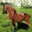

In [38]:
dump_samples(eval_base, FID_DIR / "test", 4, batch=4, seed=0)
Image.open(FID_DIR / "test" / "00000.png")

In [39]:
GEN_BASE = FID_DIR / f"gen_base_class{CLASS_ID}"
GEN_FT   = FID_DIR / f"gen_ft_class{CLASS_ID}"
N_FID    = 2048

dump_samples(eval_base, GEN_BASE, N_FID, batch=256, seed=1234)
dump_samples(eval_ft,   GEN_FT,   N_FID, batch=256, seed=1234)

2048

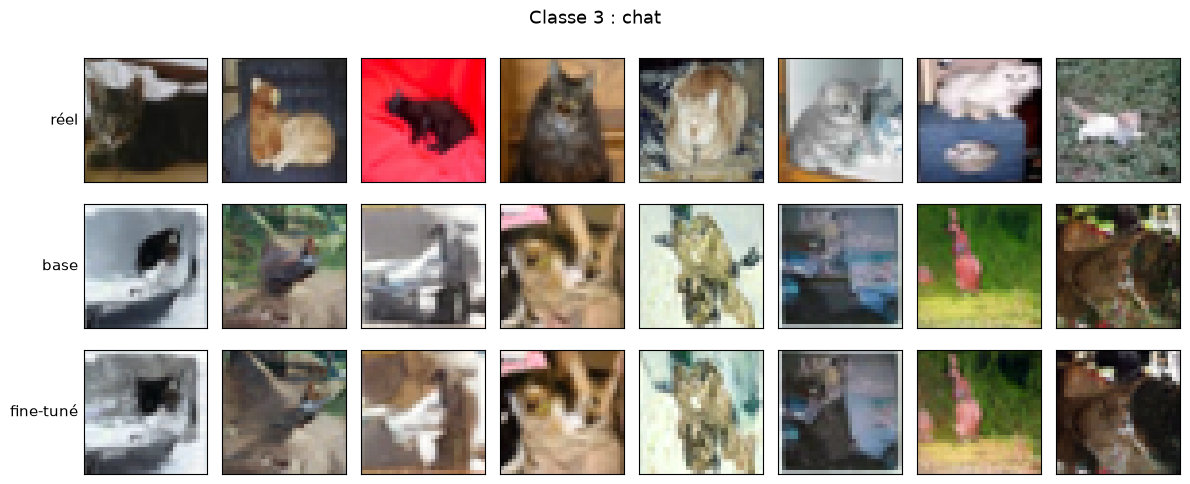

In [43]:
from PIL import Image
import matplotlib.pyplot as plt

CLASSES = ["avion", "auto", "oiseau", "chat", "cerf",
           "chien", "grenouille", "cheval", "bateau", "camion"]
rows = [("réel", REF_DIR),
        ("base",  FID_DIR / f"gen_base_class{CLASS_ID}"),
        ("fine-tuné", FID_DIR / f"gen_ft_class{CLASS_ID}")]

fig, axes = plt.subplots(3, 8, figsize=(12, 5))
for r, (label, d) in enumerate(rows):
    for j in range(8):
        axes[r, j].imshow(Image.open(d / f"{j:05d}.png"))
        axes[r, j].set_xticks([]); axes[r, j].set_yticks([])
    axes[r, 0].set_ylabel(label, rotation=0, ha="right", va="center", fontsize=11)
fig.suptitle(f"Classe {CLASS_ID} : {CLASSES[CLASS_ID]}", fontsize=13)
plt.tight_layout(); plt.show()

In [41]:
import json
json.dump({
    "class_id": CLASS_ID, "n_ref": 5000, "n_gen": N_FID, "sampling_steps": 1000,
    "fid_floor_ref_vs_ref": 21.70,
    "fid_base": 79.23, "fid_ft": 50.74,
    "ft_epochs": ft_epochs, "ft_lr": ft_lr, "ft_ema_decay": ft_ema_decay,
    "ft_history": ft_history,
    "notes": "pytorch-fid patché (scipy sqrtm disp supprimé)",
}, open(FID_DIR / "results.json", "w"), indent=2)

Code à tourner dans la console

`pip install pytorch-fid`

`python -m pytorch_fid REF_DIR GEN_DIR --device cuda --batch-size 64`